# **Importing the dataset with Data Augmentation**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings

# Suppress all warnings
warnings.filterwarnings("ignore")

# Define the paths
train_dir = '/content/drive/MyDrive/alzheimer dataset/train'
test_dir = '/content/drive/MyDrive/alzheimer dataset/test'

# Create an ImageDataGenerator object for data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.4,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=90,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)

# Load the images and labels, ensuring grayscale (1 color channel)
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),        # Resize images to 128x128
    color_mode='grayscale',        # ✅ Load as grayscale
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    color_mode='grayscale',        # ✅ Load as grayscale
    class_mode='categorical',
)


Found 4647 images belonging to 4 classes.
Found 1230 images belonging to 4 classes.


# **Model Building**

# **VGG16 Original**

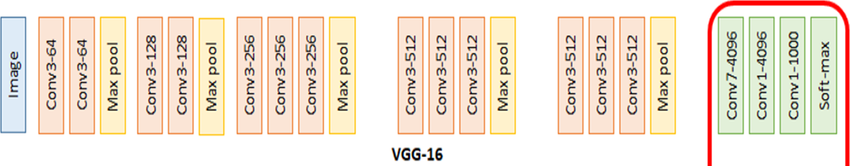

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import MaxPooling2D
from keras.layers import Dense
import numpy as np

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# VGG-16 style model implemented as a Sequential model
# Matches the original VGG-16 block structure shown in your snippet

input_shape = (128, 128,1)  # change if you need different input size
num_classes = 4  # change to the number of output classes you need

model = Sequential()

# Block 1
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Classification head
model.add(Flatten())
model.add(Dense(units=4096, activation='relu'))
model.add(Dense(units=4096, activation='relu'))
model.add(Dense(units=num_classes, activation='softmax'))

# Compile (use appropriate loss for your labels; if binary labels use 'categorical_crossentropy' only when one-hot encoded)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display summary
model.summary()


I0000 00:00:1763045111.779039     533 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763045111.779713     533 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │        16,388 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,069,764 (248.22 MB)

 Trainable params: 65,069,764 (248.22 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(train_generator,epochs=50)

Epoch 1/50


I0000 00:00:1763045119.997332     599 service.cc:148] XLA service 0x7af5580052a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763045119.997375     599 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1763045119.997380     599 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1763045120.589057     599 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763045140.572964     599 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


146/146 ━━━━━━━━━━━━━━━━━━━━ 61s 247ms/step - accuracy: 0.4906 - loss: 1.6056
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.5900 - loss: 0.9859
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 172ms/step - accuracy: 0.5955 - loss: 0.9769
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 174ms/step - accuracy: 0.6057 - loss: 0.9592
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 26s 175ms/step - accuracy: 0.5973 - loss: 0.9778
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 174ms/step - accuracy: 0.5811 - loss: 0.9974
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5989 - loss: 0.9690
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5864 - loss: 0.9838
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5928 - loss: 0.9902
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5851 - loss: 1.0035
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 25s 173ms/step - accuracy: 0.5891 - loss: 0.9859
Epoch 12/50
146/146 ━━━━━━━━━━

In [ ]:
# Evaluate the model on the test data
loss, accuracy_vgg = model.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of VGG16 Original: {accuracy_vgg}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 221ms/step - accuracy: 0.3831 - loss: 1.1994
Test Accuracy of VGG16 Original: 0.37560975551605225


You can add BatchNorm + Dropout + smaller Dense layers.

For example:

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential()

# Block 1
model.add(Conv2D(64, (3,3), padding="same", activation="relu", input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(Conv2D(64, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Block 2
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(128, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Block 3
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(256, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Block 4 (you *can* drop one of the 512 blocks if data is small)
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(Conv2D(512, (3,3), padding="same", activation="relu"))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))

# Global part
model.add(Flatten())
model.add(Dense(1024, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(512, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(4, activation="softmax"))


Option 2:

Use GlobalAveragePooling2D instead of Flatten

In [ ]:
from tensorflow.keras.layers import GlobalAveragePooling2D

# ... conv blocks as before ...

model.add(GlobalAveragePooling2D())
model.add(Dense(256, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(4, activation="softmax"))


Option 3:

Consider transfer learning (especially if data is limited)

**How to use GlobalAveragePooling:**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

model.add(GlobalAveragePooling2D())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax'))


# **VGG 19 Original**

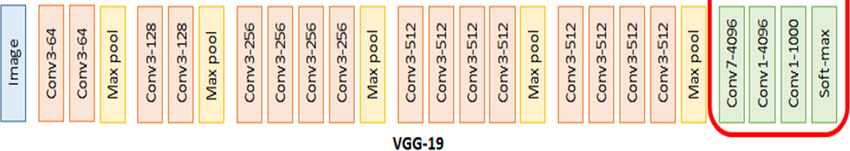

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [ ]:
model = Sequential()

model.add(Conv2D(filters = 64, kernel_size=(3,3), strides = 1, padding='same', input_shape = (128,128,1), activation = 'relu'))
model.add(Conv2D(filters = 64, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2))

model.add(Conv2D(filters = 128, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 128, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2))

model.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2,2),strides = 2))

model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))

model.add(MaxPooling2D(pool_size = (2,2),strides = 2))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
model.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))

model.add(MaxPooling2D(pool_size = (2,2),strides = 2))
model.add(Flatten())
model.add(Dense(units = 4096,activation = 'relu'))
model.add(Dense(units = 4096,activation = 'relu'))
model.add(Dense(units = 4,activation = 'softmax'))

# Compile (use appropriate loss for your labels; if binary labels use 'categorical_crossentropy' only when one-hot encoded)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display summary
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 128, 128, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4096)           │    33,558,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │        16,38

 Total params: 70,379,460 (268.48 MB)

 Trainable params: 70,379,460 (268.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.fit(train_generator,epochs=50)

Epoch 1/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 40s 225ms/step - accuracy: 0.5121 - loss: 1.1281
Epoch 2/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.5820 - loss: 0.9936
Epoch 3/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 221ms/step - accuracy: 0.5900 - loss: 0.9880
Epoch 4/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 215ms/step - accuracy: 0.5941 - loss: 0.9748
Epoch 5/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 32s 219ms/step - accuracy: 0.5889 - loss: 0.9797
Epoch 6/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 215ms/step - accuracy: 0.5942 - loss: 0.9762
Epoch 7/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.5952 - loss: 0.9686
Epoch 8/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.6017 - loss: 0.9769
Epoch 9/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.5862 - loss: 0.9927
Epoch 10/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - accuracy: 0.5838 - loss: 0.9840
Epoch 11/50
146/146 ━━━━━━━━━━━━━━━━━━━━ 31s 214ms/step - accuracy: 0.5763 - loss: 0.9986
Epoch 12/50
146/146

In [ ]:
# Evaluate the model on the test data
loss, accuracy_vgg19 = model.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of VGG19 Original: {accuracy_vgg19}")


39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.3839 - loss: 1.2103
Test Accuracy of VGG19 Original: 0.37560975551605225


**